## 1. Imports & Paths

In [1]:
import os, sys, warnings
import numpy as np
import cv2
import torch
import pandas as pd
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = os.path.abspath(".")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f"ROOT: {ROOT}")
print(f"CUDA: {torch.cuda.is_available()}")

ROOT: d:\UITs subject\Năm 3\Nhận dạng\SoccerMOT_Baseline
CUDA: True


In [2]:
BASE         = r"D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT"
BEST_PATH    = r"D:\UITs subject\Năm 3\Nhận dạng\SoccerMOT_Baseline\src\models\best.pt"
YOLOv5M_PATH = r"D:\UITs subject\Năm 3\Nhận dạng\SoccerMOT_Baseline\src\models\yolov5m.pt"

VIDEOS_DIR = os.path.join(BASE, r"Data\wide_view\videos")
GT_DIR     = os.path.join(BASE, r"Data\wide_view\annotations")
OUTPUT_DIR = os.path.join(BASE, r"Output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

ALL_VIDEOS  = sorted([f for f in os.listdir(VIDEOS_DIR) if f.endswith(('.mp4', '.avi'))])
TEST_VIDEOS = ALL_VIDEOS[-6:]   

print(f"Found {len(ALL_VIDEOS)} videos total")
print(f"Test videos ({len(TEST_VIDEOS)}): {TEST_VIDEOS}")

VIDEO_PATH  = os.path.join(VIDEOS_DIR, TEST_VIDEOS[0])
GT_CSV_PATH = os.path.join(GT_DIR, TEST_VIDEOS[0].replace(".mp4","").replace(".avi","") + ".csv")
print(f"Sample video : {VIDEO_PATH}")
print(f"GT CSV       : {GT_CSV_PATH}")

Found 66 videos total
Test videos (6): ['F_20220220_1_1800_1830.mp4', 'F_20220220_1_1830_1860.mp4', 'F_20220220_1_1860_1890.mp4', 'F_20220220_1_1890_1920.mp4', 'F_20220220_1_1920_1950.mp4', 'F_20220220_1_1950_1980.mp4']
Sample video : D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT\Data\wide_view\videos\F_20220220_1_1800_1830.mp4
GT CSV       : D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT\Data\wide_view\annotations\F_20220220_1_1800_1830.csv


## 2. Homography Matrix

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
FRAME_W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
FRAME_H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS     = cap.get(cv2.CAP_PROP_FPS)
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
 
print(f"Video size : {FRAME_W} × {FRAME_H}")
print(f"FPS        : {FPS:.1f}")
print(f"Frames     : {N_FRAMES}")

Video size : 6500 × 1000
FPS        : 25.0
Frames     : 750


In [4]:
from src.pitch_localization import load_homography
 
# fisheye_keypoints.json chứa pixel coords của video wide_view (~6500×1000)
KEYPOINTS_PATH = os.path.join(BASE, r"Data\fisheye_keypoints.json")
H, H_inv = load_homography(KEYPOINTS_PATH)
print(f"H loaded. Shape: {H.shape}")
 
# Kiểm tra nhanh: pixel (3540, 899) → pitch nên ra (~52.5, ~68)
from src.pitch_localization import box_to_pitch_xy
test = box_to_pitch_xy([3540-50, 831, 100, 68], H=H, frame_w=FRAME_W, frame_h=FRAME_H)
print(f"Sanity check — pitch coords: {test.round(2)}  (expect ~[52.5, 68.0])")

[pitch_localization] H computed — inliers: 62/65
H loaded. Shape: (3, 3)
Sanity check — pitch coords: [52.65 68.39]  (expect ~[52.5, 68.0])


## 3. Khởi tạo Components

In [12]:
from src.detector import Detector
from src.feature_extractor import FeatureExtractor
 
_device = "cuda" if torch.cuda.is_available() else "cpu"

detector_trained = Detector(
    backend    = "yolov5",
    model_path = BEST_PATH,
    conf       = 0.4,
    iou        = 0.5,
    imgsz      = 1600,
    device     = _device,
)

detector_pretrained = Detector(
    backend    = "yolov5_hub",
    model_path = YOLOv5M_PATH,
    conf       = 0.4,
    iou        = 0.5,
    imgsz      = 1600,
    device     = _device,
)
 
extractor_osnet = FeatureExtractor(
    backend    = "osnet",
    model_name = "osnet_x1_0",
    device     = "auto",
)

[Detector] YOLOv5-ultralytics loaded | model=D:\UITs subject\Năm 3\Nhận dạng\SoccerMOT_Baseline\src\models\best.pt | device=cuda | conf=0.4 iou=0.5 imgsz=1600
[Detector] YOLOv5-hub loaded | model=D:\UITs subject\Năm 3\Nhận dạng\SoccerMOT_Baseline\src\models\yolov5m.pt | device=cuda | conf=0.4 iou=0.5 imgsz=1600
[FeatureExtractor] Loading osnet_x1_0 pretrained ...
Successfully loaded imagenet pretrained weights from "C:\Users\Admin/.cache\torch\checkpoints\osnet_x1_0_imagenet.pth"
[FeatureExtractor] Ready on cuda


In [14]:
TRACKER_KWARGS = dict(
    use_project         = True,
    frame_w             = FRAME_W,
    frame_h             = FRAME_H,
    n_init              = 1,
    track_high_thresh   = 0.6,   
    new_track_thresh    = 0.65, 
    max_age             = 60,
    max_cosine_distance = 0.4,
    max_iou_distance    = 0.7,   
)
 
print("Tracker kwargs:")
for k, v in TRACKER_KWARGS.items():
    if k not in ('H', 'H_inv'):
        print(f"  {k}: {v}")

Tracker kwargs:
  use_project: True
  frame_w: 6500
  frame_h: 1000
  n_init: 1
  track_high_thresh: 0.6
  new_track_thresh: 0.65
  max_age: 60
  max_cosine_distance: 0.4
  max_iou_distance: 0.7


## 4. Quick Test — 1 video, 1 pipeline

In [15]:
## 4. Quick Test — 1 video, chỉ pretrained
from src.utils import run_pipeline

result_pretrained = run_pipeline(
    video_path     = VIDEO_PATH,
    gt_csv_path    = GT_CSV_PATH,
    detector       = detector_pretrained,
    tracker_name   = "deepsort",
    output_path    = os.path.join(OUTPUT_DIR, "result_yolov5m_deepsort_osnet.avi"),
    extractor      = extractor_osnet,
    refiner        = None,
    tracker_kwargs = TRACKER_KWARGS,
    visualize      = True,
)

print("\n=== yolov5m.pt (pretrained) + DeepSORT + OSNet ===")
for k, v in result_pretrained["metrics"].items():
    print(f"  {k}: {v}")


PIPELINE: YOLOV5_HUB → OSNET → DEEPSORT
  frame_w=6500  frame_h=1000  use_project=True
[Tracker] deepsort initialized | use_project=True
[MOT] Processing frame 749
[MOT] Done — 750 frames, 27 tracks
[Visualize] Saved: D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT\Output\result_yolov5m_deepsort_osnet.avi
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 4457 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT PIPELINE
  MOTA  :    -1.50 %
  MOTP  :    60.72 %
  IDF1  :    13.63 %
  HOTA  :     5.35 %
  IDs   :        5
  FP    :     2350
  FN    :    14393
  GT    :    16500

=== yolov5m.pt (pretrained) + DeepSORT + OSNet ===
  MOTA: -1.5
  MOTP: 60.72
  IDF1: 13.63
  HOTA: 5.35
  IDs: 5
  FP: 2350
  FN: 14393
  GT: 16500


## 5. Chạy nhiều video & lấy trung bình

In [16]:
def run_multi_video(videos, detector, extractor, tracker_kwargs,
                    output_dir, detector_name="detector"):
    per_video = {}
    accum     = {}
 
    for vid in videos:
        vpath  = os.path.join(VIDEOS_DIR, vid)
        gtpath = os.path.join(GT_DIR, vid.replace(".mp4","").replace(".avi","") + ".csv")
        if not os.path.exists(gtpath):
            print(f"[SKIP] GT không tìm thấy: {gtpath}")
            continue
 
        # ── ĐỌC KÍCH THƯỚC VIDEO TỪNG FILE ──────────────────
        # BUG CŨ: dùng chung FRAME_W/FRAME_H → sai nếu video khác kích thước
        cap_tmp = cv2.VideoCapture(vpath)
        fw = int(cap_tmp.get(cv2.CAP_PROP_FRAME_WIDTH))
        fh = int(cap_tmp.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap_tmp.release()
 
        kw = {**tracker_kwargs, "frame_w": fw, "frame_h": fh}
        print(f"\n[Video] {vid} — {fw}×{fh}")
 
        r = run_pipeline(
            video_path     = vpath,
            gt_csv_path    = gtpath,
            detector       = detector,
            tracker_name   = "deepsort",
            output_path    = os.path.join(output_dir,
                             f"{os.path.splitext(vid)[0]}_{detector_name}_deepsort.avi"),
            extractor      = extractor,
            refiner        = None,
            tracker_kwargs = kw,
            visualize      = False,
        )
 
        per_video[vid] = r["metrics"]
        for k, v in r["metrics"].items():
            if isinstance(v, (int, float)):
                accum.setdefault(k, []).append(v)
 
    avg = {k: float(np.mean(vs)) for k, vs in accum.items()}
    print(f"\n{'='*55}")
    print(f"AVERAGE — {detector_name} + OSNet + DeepSORT:")
    for k, v in avg.items():
        print(f"  {k}: {v:.2f}")
    print(f"{'='*55}")
    return {"per_video": per_video, "average": avg}
 

In [17]:
multi_pretrained = run_multi_video(
    videos         = TEST_VIDEOS,   
    detector       = detector_pretrained,
    extractor      = extractor_osnet,
    tracker_kwargs = TRACKER_KWARGS,
    output_dir     = OUTPUT_DIR,
    detector_name  = "yolov5m",
)


[Video] F_20220220_1_1800_1830.mp4 — 6500×1000

PIPELINE: YOLOV5_HUB → OSNET → DEEPSORT
  frame_w=6500  frame_h=1000  use_project=True
[Tracker] deepsort initialized | use_project=True
[MOT] Processing frame 749
[MOT] Done — 750 frames, 27 tracks
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 4457 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT PIPELINE
  MOTA  :    -1.50 %
  MOTP  :    60.72 %
  IDF1  :    13.63 %
  HOTA  :     5.35 %
  IDs   :        5
  FP    :     2350
  FN    :    14393
  GT    :    16500

[Video] F_20220220_1_1830_1860.mp4 — 6500×1000

PIPELINE: YOLOV5_HUB → OSNET → DEEPSORT
  frame_w=6500  frame_h=1000  use_project=True
[Tracker] deepsort initialized | use_project=True
[MOT] Processing frame 749
[MOT] Done — 750 frames, 23 tracks
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 4943 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT

In [18]:
multi_trained = run_multi_video(
    videos         = TEST_VIDEOS,
    detector       = detector_trained,
    extractor      = extractor_osnet,
    tracker_kwargs = TRACKER_KWARGS,
    output_dir     = OUTPUT_DIR,
    detector_name  = "best",
)


[Video] F_20220220_1_1800_1830.mp4 — 6500×1000

PIPELINE: YOLOV5 → OSNET → DEEPSORT
  frame_w=6500  frame_h=1000  use_project=True
[Tracker] deepsort initialized | use_project=True
[MOT] Processing frame 749
[MOT] Done — 750 frames, 90 tracks
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 14642 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT PIPELINE
  MOTA  :    60.73 %
  MOTP  :    69.20 %
  IDF1  :    49.61 %
  HOTA  :    14.85 %
  IDs   :       34
  FP    :     2294
  FN    :     4152
  GT    :    16500

[Video] F_20220220_1_1830_1860.mp4 — 6500×1000

PIPELINE: YOLOV5 → OSNET → DEEPSORT
  frame_w=6500  frame_h=1000  use_project=True
[Tracker] deepsort initialized | use_project=True
[MOT] Processing frame 749
[MOT] Done — 750 frames, 67 tracks
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 15056 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT PIPEL

## 6. Bảng kết quả tổng hợp

In [19]:
## 6. Bảng kết quả đẹp hơn — so sánh 2 detector
def make_comparison_table(results_dict):
    """
    results_dict = {"best.pt": multi_trained, "yolov5m.pt": multi_pretrained}
    """
    import pandas as pd
    from IPython.display import display, HTML

    all_rows = []
    for detector_name, multi_result in results_dict.items():
        for vid, m in multi_result["per_video"].items():
            all_rows.append({
                "Detector" : detector_name,
                "Video"    : vid.replace("F_20220220_1_","").replace(".mp4",""),
                "MOTA"     : m["MOTA"],
                "MOTP"     : m["MOTP"],
                "IDF1"     : m["IDF1"],
                "HOTA"     : m["HOTA"],
                "IDs"      : m["IDs"],
                "FP"       : m["FP"],
                "FN"       : m["FN"],
            })
        avg = multi_result["average"]
        all_rows.append({
            "Detector" : detector_name,
            "Video"    : "★ AVERAGE",
            "MOTA"     : avg["MOTA"],
            "MOTP"     : avg["MOTP"],
            "IDF1"     : avg["IDF1"],
            "HOTA"     : avg["HOTA"],
            "IDs"      : avg["IDs"],
            "FP"       : avg["FP"],
            "FN"       : avg["FN"],
        })

    df = pd.DataFrame(all_rows).set_index(["Detector", "Video"])

    styled = (df.style
        .format({
            "MOTA": "{:.2f}",
            "MOTP": "{:.2f}",
            "IDF1": "{:.2f}",
            "HOTA": "{:.2f}",
            "IDs" : "{:.0f}",
            "FP"  : "{:.0f}",
            "FN"  : "{:.0f}",
        })
        .background_gradient(subset=["MOTA","IDF1","HOTA"], cmap="RdYlGn")
        .background_gradient(subset=["FP","FN"], cmap="RdYlGn_r")
        .background_gradient(subset=["MOTP"], cmap="Blues")
        .set_caption("So sánh best.pt vs yolov5m.pt — DeepSORT + OSNet")
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size","14px"),("font-weight","bold"),
                       ("text-align","center"),("padding","10px")]},
            {"selector": "th",
             "props": [("background-color","#2c2c2c"),("color","white"),
                       ("font-size","12px"),("text-align","center")]},
            {"selector": "tr:hover td",
             "props": [("background-color","#f0f0f0")]},
        ])
    )
    display(styled)

make_comparison_table({
    "best.pt (trained)"   : multi_trained,
    "yolov5m.pt (pretrained)": multi_pretrained,
})

## 8. Tactical Map — Trajectory trên pitch


PIPELINE: YOLOV5 → OSNET → DEEPSORT
  frame_w=6500  frame_h=1000  use_project=True
[Tracker] deepsort initialized | use_project=True
[MOT] Processing frame 749
[MOT] Done — 750 frames, 90 tracks
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 14642 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT PIPELINE
  MOTA  :    60.73 %
  MOTP  :    69.20 %
  IDF1  :    49.61 %
  HOTA  :    14.85 %
  IDs   :       34
  FP    :     2294
  FN    :     4152
  GT    :    16500
[TacticalMap] Saved: D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT\Output\tactical_map_best.png


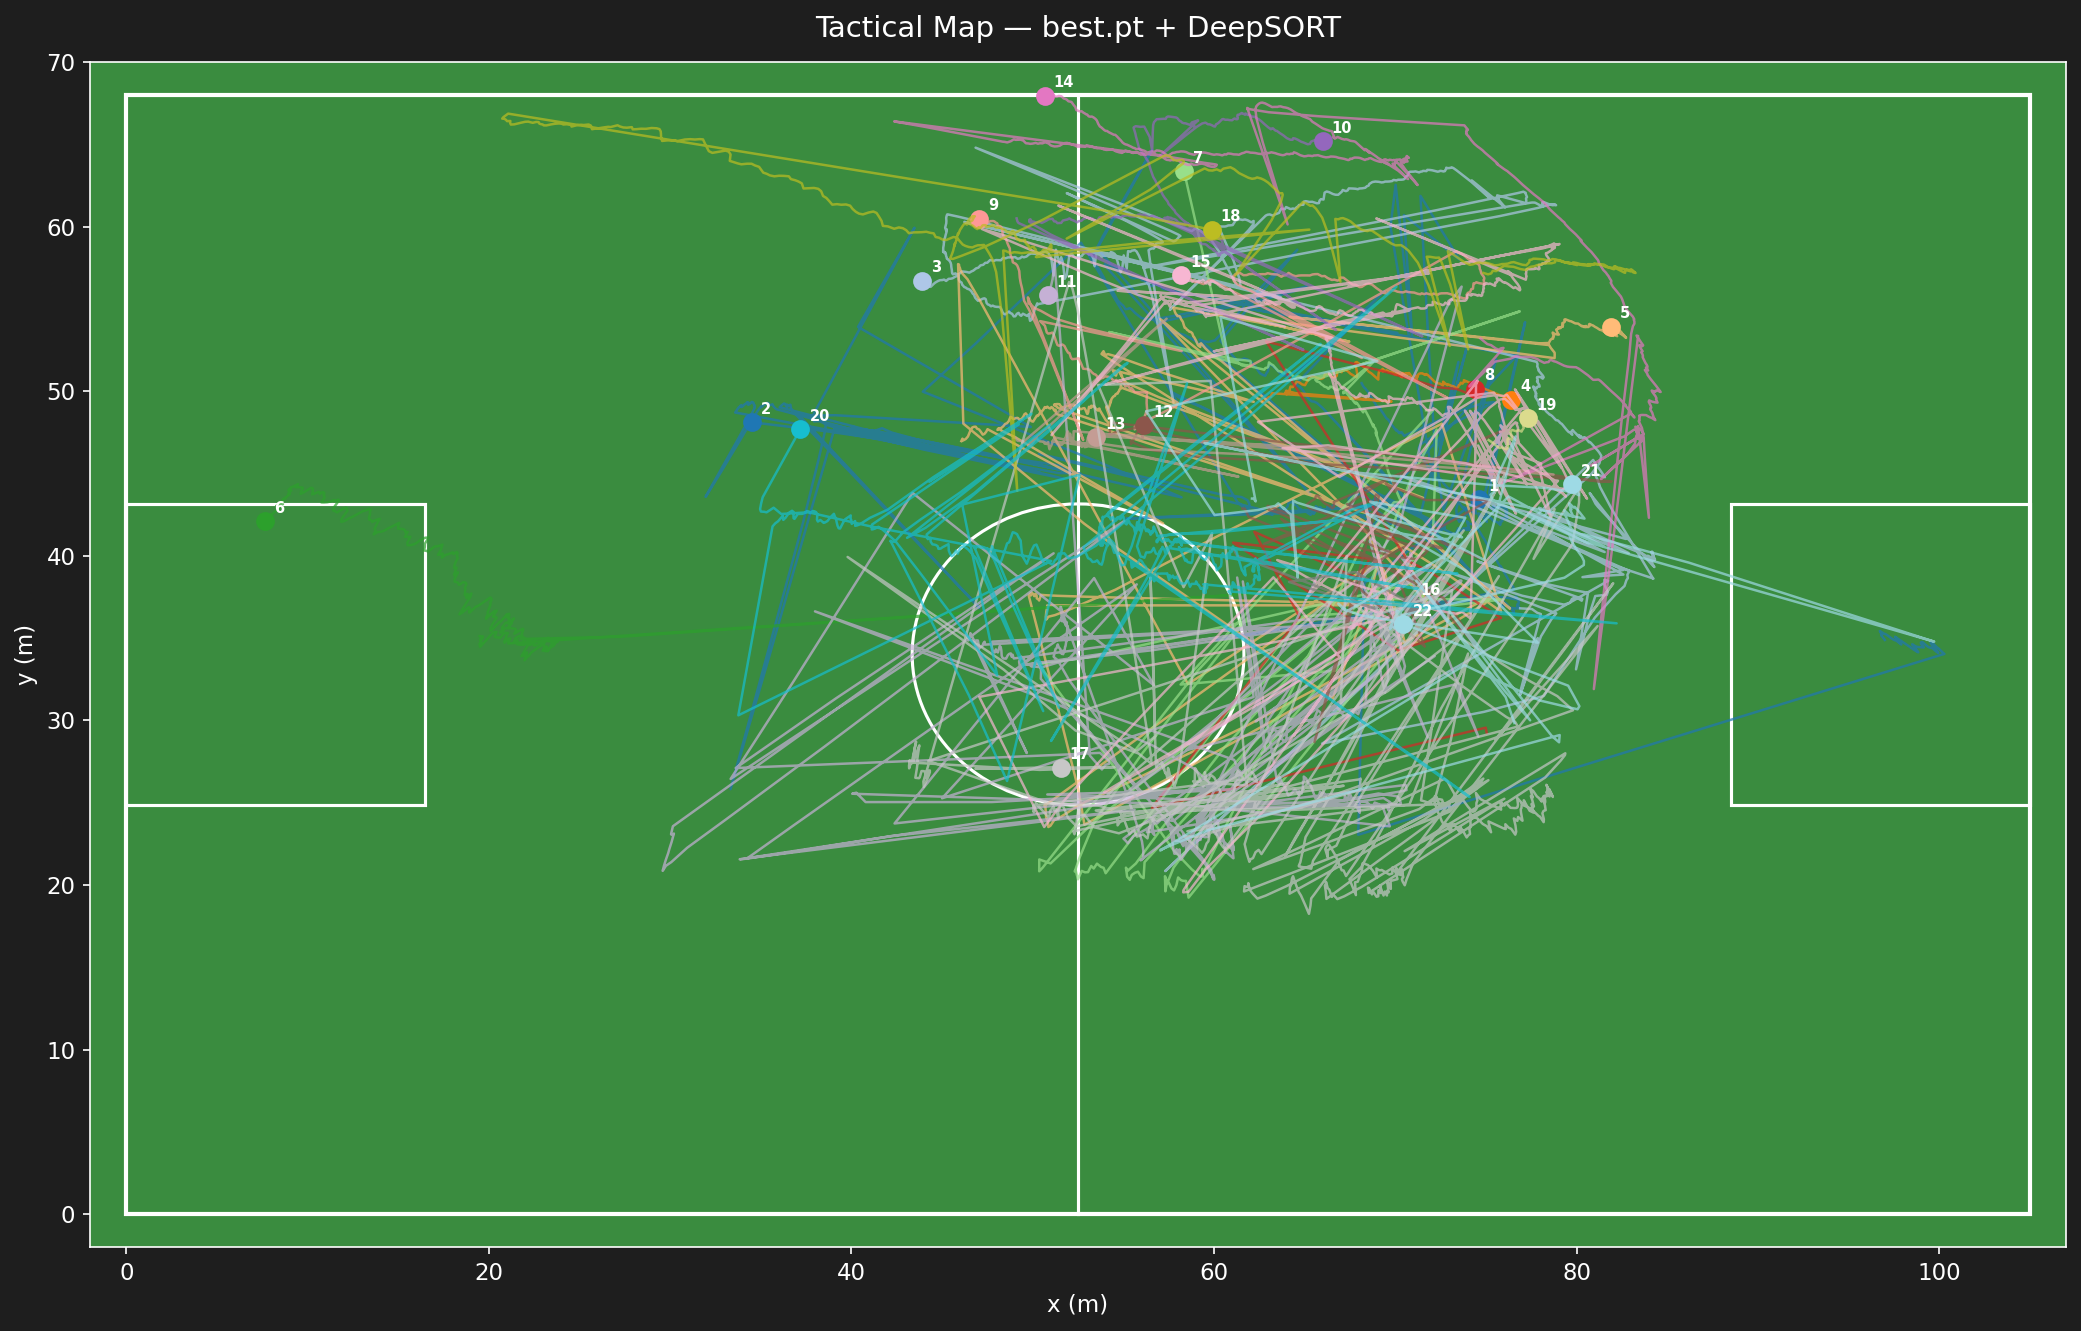

In [22]:
## 8. Tactical Map — fix plt.show() không hiện
%matplotlib inline
import matplotlib
matplotlib.use("Agg")   # ← render sang file thay vì cửa sổ
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from src.pitch_localization import box_to_pitch_xy
from IPython.display import Image as IPImage, display

def plot_tactical_map(all_tracks, H, frame_w, frame_h,
                      pitch_w=105, pitch_h=68, max_tracks=22,
                      save_path=None, title="Player Trajectories"):
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_facecolor("#3a8c3f")

    # Vẽ sân
    ax.add_patch(plt.Rectangle((0,0), pitch_w, pitch_h,
                                edgecolor="white", facecolor="none", lw=2))
    ax.add_patch(plt.Rectangle((0, 24.84), 16.5, 18.32,
                                edgecolor="white", facecolor="none", lw=1.5))
    ax.add_patch(plt.Rectangle((88.5, 24.84), 16.5, 18.32,
                                edgecolor="white", facecolor="none", lw=1.5))
    ax.plot([pitch_w/2]*2, [0, pitch_h], "w-", lw=1.5)
    ax.add_patch(plt.Circle((pitch_w/2, pitch_h/2), 9.15,
                              color="white", fill=False, lw=1.5))

    # Vẽ trajectory
    colors  = cm.tab20(np.linspace(0, 1, max_tracks))
    plotted = 0
    for tid, data in sorted(all_tracks.items()):
        if plotted >= max_tracks:
            break
        pts = []
        for box in data.get("boxes", []):
            if box is None:
                continue
            x1, y1, x2, y2 = box
            xy = box_to_pitch_xy([x1, y1, x2-x1, y2-y1],
                                   H=H, frame_w=frame_w, frame_h=frame_h)
            if 0 <= xy[0] <= pitch_w and 0 <= xy[1] <= pitch_h:
                pts.append(xy)
        if len(pts) < 2:
            continue
        pts = np.array(pts)
        c   = colors[plotted % max_tracks]
        ax.plot(pts[:,0], pts[:,1], "-", color=c, lw=1.2, alpha=0.7)
        ax.plot(pts[-1,0], pts[-1,1], "o", color=c, markersize=8)
        ax.text(pts[-1,0]+0.5, pts[-1,1]+0.5, str(tid),
                fontsize=7, color="white", weight="bold")
        plotted += 1

    ax.set_xlim(-2, pitch_w+2)
    ax.set_ylim(-2, pitch_h+2)
    ax.set_title(title, fontsize=14, color="white", pad=12)
    ax.set_xlabel("x (m)", color="white")
    ax.set_ylabel("y (m)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("white")
    fig.patch.set_facecolor("#1e1e1e")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        plt.close(fig)
        print(f"[TacticalMap] Saved: {save_path}")
        display(IPImage(save_path))  # ← hiện ảnh ngay trong notebook
    else:
        plt.show()

# Vẽ cả 2
tracks_result = run_pipeline(
    video_path=VIDEO_PATH,
    gt_csv_path=GT_CSV_PATH,
    detector=detector_trained,
    tracker_name="deepsort",
    output_path=None,
    extractor=extractor_osnet,
    tracker_kwargs=TRACKER_KWARGS,
    visualize=False,
)

plot_tactical_map(
    all_tracks = tracks_result["all_tracks"],
    H          = H,
    frame_w    = FRAME_W,
    frame_h    = FRAME_H,
    title      = "Tactical Map — best.pt + DeepSORT",
    save_path  = os.path.join(OUTPUT_DIR, "tactical_map_best.png"),
)


PIPELINE: YOLOV5_HUB → OSNET → DEEPSORT
  frame_w=6500  frame_h=1000  use_project=True
[Tracker] deepsort initialized | use_project=True
[MOT] Processing frame 749
[MOT] Done — 750 frames, 27 tracks
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 4457 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT PIPELINE
  MOTA  :    -1.50 %
  MOTP  :    60.72 %
  IDF1  :    13.63 %
  HOTA  :     5.35 %
  IDs   :        5
  FP    :     2350
  FN    :    14393
  GT    :    16500
[TacticalMap] Saved: D:\UITs subject\Năm 3\Nhận dạng\CS318_RECOGNITION_SOCCERTRACK_MOT\Output\tactical_map_yolov5m.png


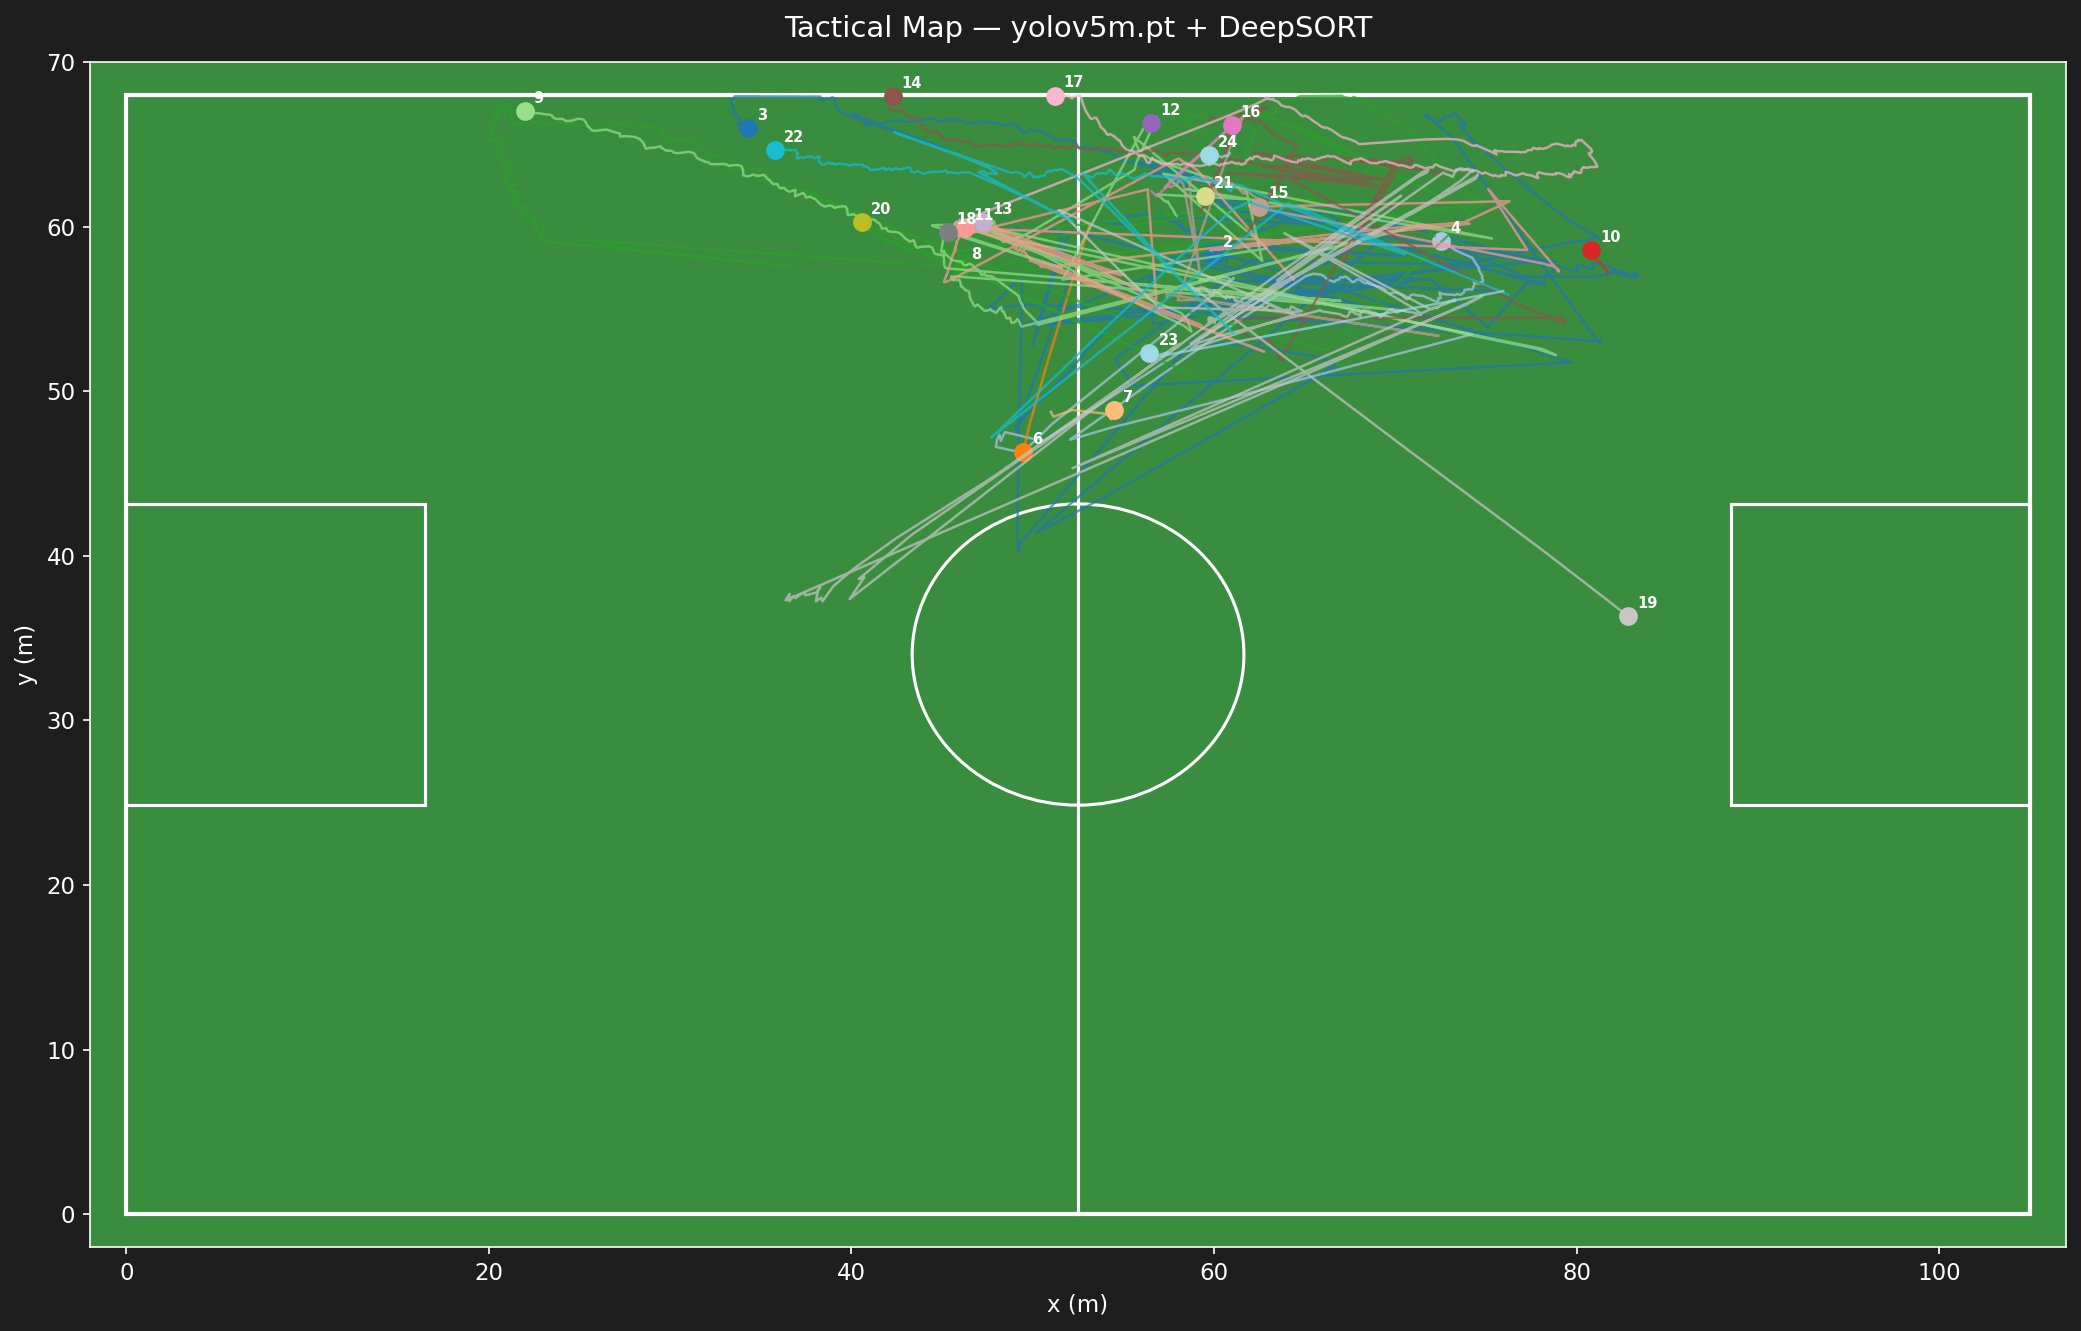

In [23]:
tracks_result_pretrained = run_pipeline(
    video_path=VIDEO_PATH,
    gt_csv_path=GT_CSV_PATH,
    detector=detector_pretrained,
    tracker_name="deepsort",
    output_path=None,
    extractor=extractor_osnet,
    tracker_kwargs=TRACKER_KWARGS,
    visualize=False,
)

plot_tactical_map(
    all_tracks = tracks_result_pretrained["all_tracks"],
    H          = H,
    frame_w    = FRAME_W,
    frame_h    = FRAME_H,
    title      = "Tactical Map — yolov5m.pt + DeepSORT",
    save_path  = os.path.join(OUTPUT_DIR, "tactical_map_yolov5m.png"),
)